# Demo: 2D image RI2FL

> 2D RI2FL demo


In [ ]:
#| default_exp tutorial_2

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import aics_pipeline, manifest2csv

from monai.utils import set_determinism

set_determinism(0)

In [ ]:
device = get_device()
print(device)

cuda


### Download Data

In [ ]:
image_path = "../_data/aics"
image_target_paths, data_manifest = aics_pipeline(6, image_path)

Loading manifest: 100%|██████████| 77165/77165 [00:01<00:00, 44.9k/s]


In [ ]:
# data_manifest.to_csv(image_path + 'aics_dataset.csv')
# manifest2csv(image_target_paths, data_manifest, "ChannelNumberBrightfield","ChannelNumber405", data_save_path=image_path+'/')

### Sorting & Preprocessing data

The downloaded images are very large, so we are going to extract only the channels we need for our model.

In [ ]:
# for each image, read channels to extract from data manifest and create the indices dict
indices_list =  []
for X, y in zip(data_manifest["ChannelNumberBrightfield"].values, data_manifest["ChannelNumber405"].values):
    indices_list.append({'C': [X, y], 'Z': 1})


[{'C': [6, 5], 'Z': 1}, {'C': [6, 5], 'Z': 1}, {'C': [6, 5], 'Z': 1}, {'C': [6, 5], 'Z': 1}, {'C': [6, 5], 'Z': 1}, {'C': [6, 5], 'Z': 1}]


In [ ]:
# extract substacks and save them in X and y folders
for filename, indices in zip(image_target_paths, indices_list):
    print(filename, ' ', indices)
    
# extract_substacks(filename, output_dir=['X', 'y'], indices=indices, split_dimension="C")

../_data/aics/6677e50c_3500001004_100X_20170623_5-Scene-1-P24-E06.ome.tiff   {'C': [6, 5], 'Z': 1}
../_data/aics/8e39ca91_3500001004_100X_20170623_5-Scene-3-P26-F05.ome.tiff   {'C': [6, 5], 'Z': 1}
../_data/aics/c679e884_3500001004_100X_20170623_1-Scene-8-P8-E04.ome.tiff   {'C': [6, 5], 'Z': 1}
../_data/aics/4e019af4_3500001004_100X_20170623_8-Scene-6-P45-F06.ome.tiff   {'C': [6, 5], 'Z': 1}
../_data/aics/c12715d4_3500001004_100X_20170623_5-Scene-7-P30-F05.ome.tiff   {'C': [6, 5], 'Z': 1}
../_data/aics/2cad3afd_3500001004_100X_20170623_5-Scene-6-P29-F05.ome.tiff   {'C': [6, 5], 'Z': 1}


### Create Dataloader

In [ ]:
bs, size = 1, 16

itemTfms = [RandCropND(size), ScaleIntensity(min=0.0, max=1.0), RandRot90(prob=0.5), RandFlip(prob=0.75)]

data = BioDataLoaders.from_csv(
    image_path, 
    csv_fname='train.csv', 
    header='infer',
    pref='./',
    item_tfms=itemTfms,
    batch_tfms=None,
    img_cls=BioImageStack,
    target_img_cls=BioImageStack,
    show_summary=True,
    bs=bs,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Setting-up type transforms pipelines
0  ../_data/aics/6677e50c_3500001004_100X_20170623_5-Scene-1-P24-E06.ome.tiffC6   
1  ../_data/aics/8e39ca91_3500001004_100X_20170623_5-Scene-3-P26-F05.ome.tiffC6   
2   ../_data/aics/c679e884_3500001004_100X_20170623_1-Scene-8-P8-E04.ome.tiffC6   
3  ../_data/aics/4e019af4_3500001004_100X_20170623_8-Scene-6-P45-F06.ome.tiffC6   

                                                       target (path+identifier)  
0  ../_data/aics/6677e50c_3500001004_100X_20170623_5-Scene-1-P24-E06.ome.tiffC5  
1  ../_data/aics/8e39ca91_3500001004_100X_20170623_5-Scene-3-P26-F05.ome.tiffC5  
2   ../_data/aics/c679e884_3500001004_100X_20170623_1-Scene-8-P8-E04.ome.tiffC5  
3  ../_data/aics/4e019af4_3500001004_100X_20170623_8-Scene-6-P45-F06.ome.tiffC5  
Found 4 items
2 datasets of sizes 4,0
Setting up Pipeline: ColReader -- {'cols': 0, 'pref': './', 'suff': '', 'label_delim': None} -> BioImageBase.create -> Tensor2BioImage -- {}


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


Setting up Pipeline: ColReader -- {'cols': 1, 'pref': './', 'suff': '', 'label_delim': None} -> BioImageBase.create -> Tensor2BioImage -- {}


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


...


Building one batch
Applying item_tfms to the first sample:


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


  Pipeline: ScaleIntensity -> RandCropND -- {'size': (16, 16, 16), 'lazy': False, 'p': 1.0} -> RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0, 1), 'ndim': 2, 'lazy': False, 'p': 1.0} -> RandFlip -- {'prob': 0.75, 'spatial_axis': None, 'ndim': 2, 'lazy': False, 'p': 1.0} -> ToTensor
    starting from
      (BioImageStack of size 1x65x624x924, BioImageStack of size 1x65x624x924)
    applying ScaleIntensity gives
      (BioImageStack of size 1x65x624x924, BioImageStack of size 1x65x624x924)
    applying RandCropND -- {'size': (16, 16, 16), 'lazy': False, 'p': 1.0} gives
      (BioImageStack of size 1x16x16x16, BioImageStack of size 1x16x16x16)
    applying RandRot90 -- {'prob': 0.5, 'max_k': 3, 'spatial_axes': (0, 1), 'ndim': 2, 'lazy': False, 'p': 1.0} gives
      (BioImageStack of size 1x16x16x16, BioImageStack of size 1x16x16x16)
    applying RandFlip -- {'prob': 0.75, 'spatial_axis': None, 'ndim': 2, 'lazy': False, 'p': 1.0} gives
      (BioImageStack of size 1x16x16x16, Bi

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (con


No before_batch transform to apply

Collating items in a batch

No batch_tfms to apply
None
train images: 4 
validation images: 0


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


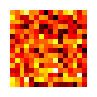

In [ ]:
data.show_batch(max_n=2, cmap='hot')

### Load and train a 2D model

In [ ]:
from bioMONAI.nets import Deeplab, DeeplabConfig

In [ ]:
config_2d = DeeplabConfig(
    dimensions=3,
    in_channels=1,  
    out_channels=1,
    backbone="resnet10",  
    aspp_dilations=[1]
)
model = Deeplab(config_2d)
loss = MSSSIML1Loss(2, levels=2) #CombinedLoss(alpha=0, beta=0.5)
metrics = [SSIMMetric, MSELoss]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

NameError: name 'MSSSIML1Loss' is not defined

In [ ]:
trainer.fit_flat_cos(1)

epoch,train_loss,valid_loss,SSIM,MSELoss,time


Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (con

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 256, 1, 1, 1])

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!